# This notebook will serve to explore Cary's Food Waste Recycling API

In [2]:
# import relevant libraries
import requests
import pandas as pd
import seaborn as sns
import plotly.express as px
import os

In [3]:
# Base URL for Cary's Food Waste Recycling Data
cary_base_url = 'https://data.townofcary.org/api/explore/v2.1/catalog/datasets/food-waste-pilot'

# We have two endpoints, but we're going to focus on using the 'exports' endpoint to evaluate the entire dataset
records_endpoint = '/records'
json_exports_endpoint = '/exports/json'

# We store our response from the API in a variable and we store it as json
response = requests.get(cary_base_url + json_exports_endpoint)
json_data = response.json()

In [4]:
type(json_data[0])

dict

In [5]:
df = pd.DataFrame(json_data)

In [6]:
df.head()

,stop_name,date_collection_datetime,lbs_collected,compost_created_lbs
0,Citizen's Convenience Center,2022-02-18,202.8,20.0
1,Citizen's Convenience Center,2022-02-25,250.8,25.0
2,Citizen's Convenience Center,2022-02-28,213.8,21.0
3,Citizen's Convenience Center,2022-03-21,601.2,60.0
4,Citizen's Convenience Center,2022-03-30,610.8,61.0


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 956 entries, 0 to 955
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   stop_name                 956 non-null    str    
 1   date_collection_datetime  956 non-null    str    
 2   lbs_collected             956 non-null    float64
 3   compost_created_lbs       956 non-null    float64
dtypes: float64(2), str(2)
memory usage: 30.0 KB


In [8]:
df.describe()

,lbs_collected,compost_created_lbs
count,956.000000,956.000000
mean,642.399059,64.209205
std,308.156512,30.815379
min,0.000000,0.000000
25%,449.750000,45.000000
50%,599.600000,60.000000
75%,763.075000,76.000000
max,2057.000000,206.000000


## Splitting date column to indicate year and month of the record.

The Descriptive statistics generated above make no sense given that entries make the most contextual sense when they're grouped by month, year, or quarter. Below I will plot a histogram of the overall dataset, then will attempt to plot histograms for the data grouped by year first.

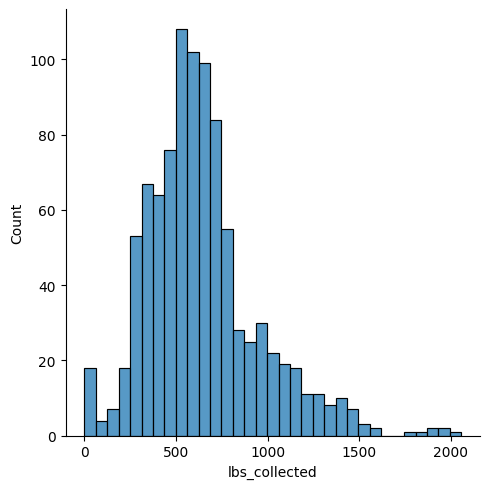

In [9]:
sns.displot(df['lbs_collected'])

In [10]:
#convert date_collection_datetime to datetime type
df['date_collection_datetime'] = pd.to_datetime(df['date_collection_datetime'])

In [11]:
# create a 'year' variable
df['year'] = df['date_collection_datetime'].dt.year

In [12]:
df.head()

,stop_name,date_collection_datetime,lbs_collected,compost_created_lbs,year
0,Citizen's Convenience Center,2022-02-18,202.8,20.0,2022
1,Citizen's Convenience Center,2022-02-25,250.8,25.0,2022
2,Citizen's Convenience Center,2022-02-28,213.8,21.0,2022
3,Citizen's Convenience Center,2022-03-21,601.2,60.0,2022
4,Citizen's Convenience Center,2022-03-30,610.8,61.0,2022


In [13]:
#subset data frame to only include pounds collected and year of collection
df_lbs_year = df[['lbs_collected', 'year']]
df_sum_lbs_year = df_lbs_year.groupby(["year"]).sum()

<Axes: xlabel='year', ylabel='lbs_collected'>

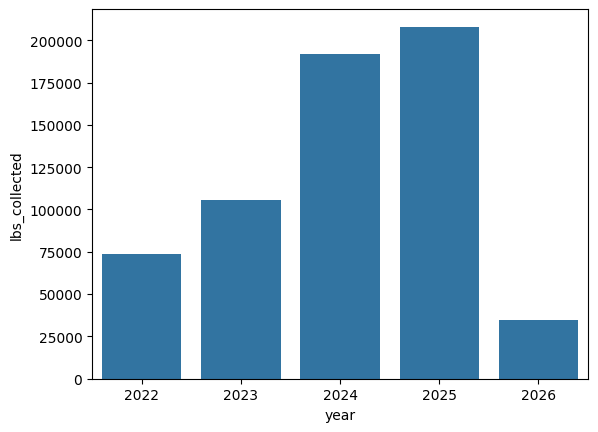

In [14]:
#generate bar plot of lbs collected by year
sns.barplot(x="year", y="lbs_collected", data=df_sum_lbs_year)

At first glance above, it seems like the Cary Composts program has resulted in a consistent increase in pounds collected over time. 2026 only looks low because there's only for the month of January.

Next, I want to dive in to take a look at the following:
- Histogram by year of collection
- boxplot grouped by both year of collection and collection site
- Lineplot of the entire dataset

## Histograms by year of collection

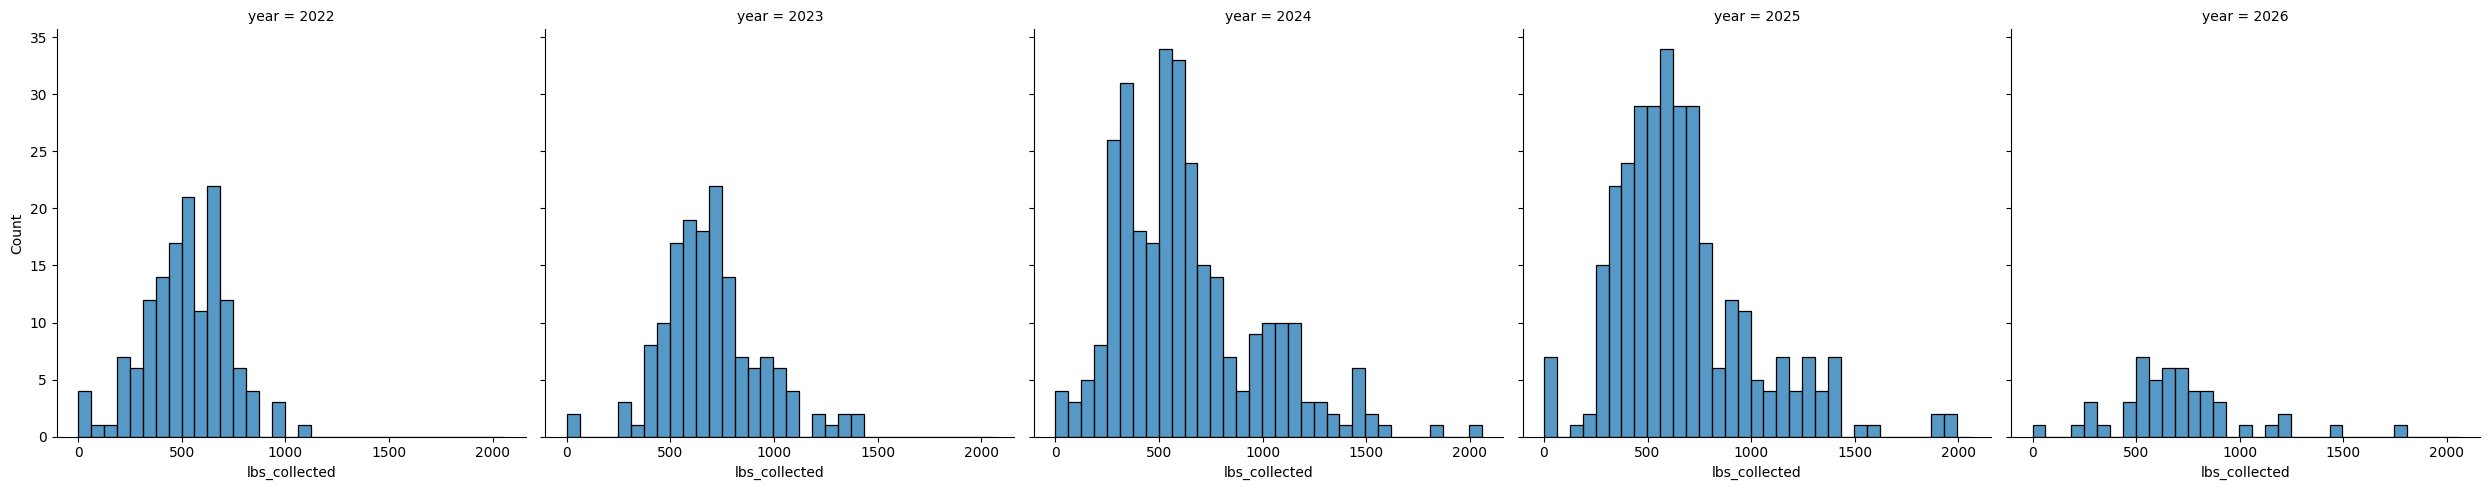

In [15]:
sns.displot(df, x='lbs_collected', col='year')

## Boxplot grouped by year and collection site

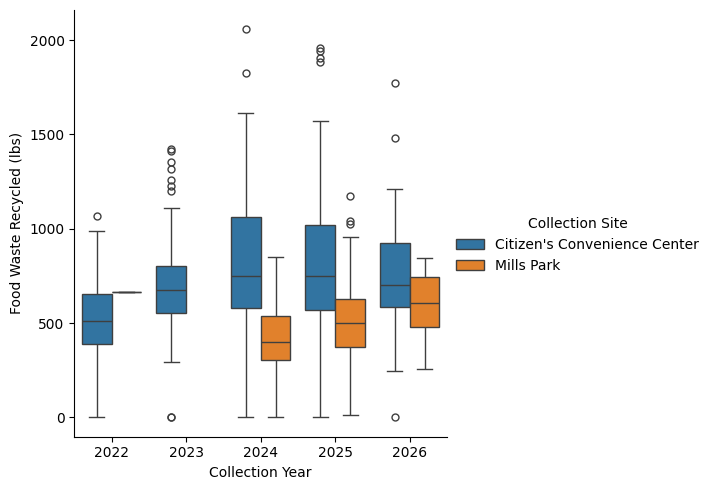

In [16]:
cat_plot_by_year_stop = sns.catplot(df, kind='box', x='year', y='lbs_collected', hue='stop_name')
cat_plot_by_year_stop.set_axis_labels('Collection Year', 'Food Waste Recycled (lbs)')
cat_plot_by_year_stop.legend.set_title("Collection Site")

<Axes: xlabel='year', ylabel='lbs_collected'>

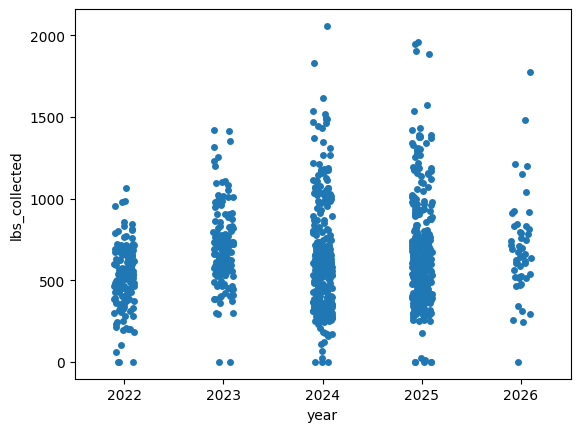

In [17]:
sns.stripplot(df, x='year', y='lbs_collected')

<Axes: ylabel='lbs_collected'>

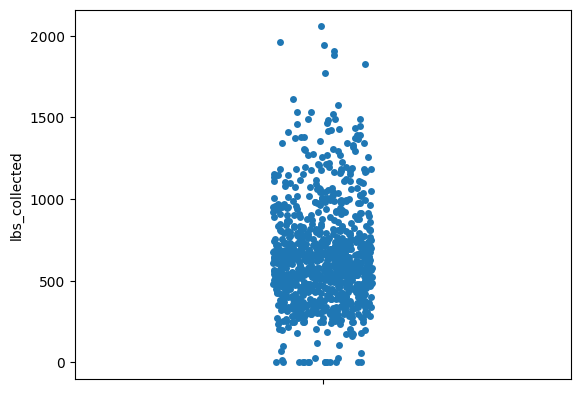

In [18]:
sns.stripplot(df['lbs_collected'])

<Axes: xlabel='date_collection_datetime', ylabel='lbs_collected'>

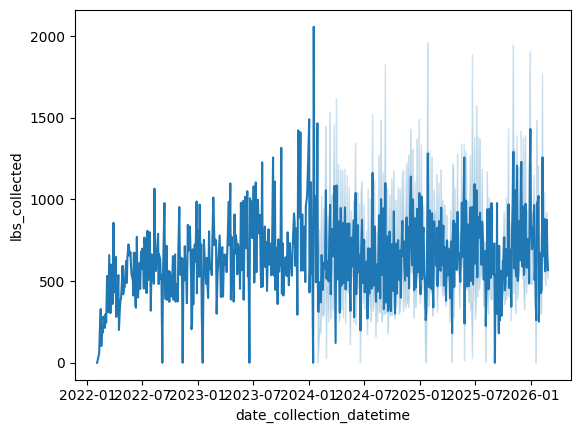

In [19]:
sns.lineplot(df, x="date_collection_datetime", y="lbs_collected")

In [20]:
df.loc[df['stop_name']=='Mills Park'].sort_values(by=["year"])

,stop_name,date_collection_datetime,lbs_collected,compost_created_lbs,year
530,Mills Park,2022-08-25,664.8,66.0,2022
56,Mills Park,2024-01-31,0.0,0.0,2024
61,Mills Park,2024-02-23,449.8,45.0,2024
60,Mills Park,2024-02-19,282.8,28.0,2024
65,Mills Park,2024-04-08,518.8,52.0,2024
...,...,...,...,...,...
549,Mills Park,2026-01-09,758.8,76.0,2026
548,Mills Park,2026-01-07,520.8,52.0,2026
836,Mills Park,2026-02-18,606.0,61.0,2026
835,Mills Park,2026-01-16,608.0,61.0,2026


Through the above table and by looking at the grouped boxplot, I've realized that there is one record in 2022 that's not accurate. There's a collection at Mills Park in 2022, which is an error because Mills Park didn't start participating in the Cary Composts program until 2024, as stated in their data story. It would be good to let the Cary people know of this.

### Trying to chart with plotly just in case it's more helpful.

While seaborn can get the job done, I want to try using plotly to make my line chart, in case it feeds off of the D3 power enough to scale the x-axis `date_collection_datetime` variable in a way that makes sense.

In [21]:
# The following is one of plotly's sample bar charts as a way to quickly show it working
fig = px.bar(x=["a", "b", "c"], y=[1, 3, 2])
fig.show()

In [22]:
#sort by date first:
df = df.sort_values(by='date_collection_datetime')
df_lineplot = px.line(df, x='date_collection_datetime', y='lbs_collected')
df_lineplot.show()

Exploring the line chart above revealed an important nature of the data, which is that after Mills Park was added, there can be multiple collections in the same day. This makes the data have completely straight vertical lines in the chart. To get a better representation of the daily fluctuation in food waste recycling, I should be adding all collections at the day level, and then rechart to notice the difference. However, before doing so, I should remove the erroneous collection record for Mills Park in 2022. It's clearly throwing the chart off as shown below, when we add lines for each stop name:



In [23]:
df_lineplot_by_stop = px.line(df, x='date_collection_datetime', y='lbs_collected', color='stop_name')
df_lineplot_by_stop.show()

In [24]:
conditions_to_remove = (df['stop_name'] == 'Mills Park') & (df['year'] == 2022)
df_cleaner = df[~conditions_to_remove]
print('df_cleaner dataframe length is: ' + str(len(df_cleaner)) + ' while df dataframe length is: ' + str(len(df)))

df_cleaner dataframe length is: 955 while df dataframe length is: 956


In [25]:
# Add fiscal_year column based on NC fiscal year (July 1 - June 30)
# FY 21-22: July 1, 2021 - June 30, 2022
# FY 22-23: July 1, 2022 - June 30, 2023
# FY 23-24: July 1, 2023 - June 30, 2024
# FY 24-25: July 1, 2024 - June 30, 2025

def get_fiscal_year(date):
    """Returns fiscal year string (e.g., '22-23') based on date."""
    year = date.year
    month = date.month
    if month >= 7:  # July-December: FY starts this calendar year
        fy_start = year
    else:  # January-June: FY started previous calendar year
        fy_start = year - 1
    fy_end = fy_start + 1
    return f"{str(fy_start)[-2:]}-{str(fy_end)[-2:]}"

df_cleaner['fiscal_year'] = df_cleaner['date_collection_datetime'].apply(get_fiscal_year)
print("Fiscal year distribution:")
print(df_cleaner['fiscal_year'].value_counts().sort_index())

Fiscal year distribution:
fiscal_year
21-22     62
22-23    153
23-24    219
24-25    312
25-26    209
Name: count, dtype: int64


In [26]:
# Convert pounds to tons (2000 lbs = 1 ton)
def calculateTonsFoodWaste(lbs):
    """Converts pounds to tons."""
    return lbs / 2000

df_cleaner['tons_collected'] = df_cleaner['lbs_collected'].apply(calculateTonsFoodWaste)
print(f"Total tons collected: {df_cleaner['tons_collected'].sum():.2f}")
print(f"\nTons collected by fiscal year:")
print(df_cleaner.groupby('fiscal_year')['tons_collected'].sum().sort_index())

Total tons collected: 306.73

Tons collected by fiscal year:
fiscal_year
21-22     13.97020
22-23     47.14130
23-24     74.23335
24-25    100.56190
25-26     70.82760
Name: tons_collected, dtype: float64


In [27]:
# Determine season based on astronomical season dates
from datetime import date

# Define season date ranges for each year (start_date, end_date, season)
season_ranges = [
    # Winter 2021-2022
    (date(2021, 12, 21), date(2022, 3, 19), 'Winter'),
    # Spring 2022
    (date(2022, 3, 20), date(2022, 6, 20), 'Spring'),
    # Summer 2022
    (date(2022, 6, 21), date(2022, 9, 21), 'Summer'),
    # Fall 2022
    (date(2022, 9, 22), date(2022, 12, 20), 'Fall'),
    # Winter 2022-2023
    (date(2022, 12, 21), date(2023, 3, 19), 'Winter'),
    # Spring 2023
    (date(2023, 3, 20), date(2023, 6, 20), 'Spring'),
    # Summer 2023
    (date(2023, 6, 21), date(2023, 9, 22), 'Summer'),
    # Fall 2023
    (date(2023, 9, 23), date(2023, 12, 20), 'Fall'),
    # Winter 2023-2024
    (date(2023, 12, 21), date(2024, 3, 18), 'Winter'),
    # Spring 2024
    (date(2024, 3, 19), date(2024, 6, 19), 'Spring'),
    # Summer 2024
    (date(2024, 6, 20), date(2024, 9, 21), 'Summer'),
    # Fall 2024
    (date(2024, 9, 22), date(2024, 12, 20), 'Fall'),
    # Winter 2024-2025
    (date(2024, 12, 21), date(2025, 3, 19), 'Winter'),
    # Spring 2025
    (date(2025, 3, 20), date(2025, 6, 19), 'Spring'),
    # Summer 2025
    (date(2025, 6, 20), date(2025, 9, 21), 'Summer'),
    # Fall 2025
    (date(2025, 9, 22), date(2025, 12, 20), 'Fall'),
    # Winter 2025-2026
    (date(2025, 12, 21), date(2026, 3, 19), 'Winter'),
    # Spring 2026
    (date(2026, 3, 20), date(2026, 6, 20), 'Spring'),
    # Summer 2026
    (date(2026, 6, 21), date(2026, 9, 21), 'Summer'),
    # Fall 2026
    (date(2026, 9, 22), date(2026, 12, 20), 'Fall'),
    # Winter 2026-2027
    (date(2026, 12, 21), date(2027, 3, 19), 'Winter'),
]

def determineSeason(dt):
    """Determines the astronomical season for a given date."""
    d = dt.date() if hasattr(dt, 'date') else dt
    for start, end, season in season_ranges:
        if start <= d <= end:
            return season
    return 'Unknown'

df_cleaner['season'] = df_cleaner['date_collection_datetime'].apply(determineSeason)
print("Season distribution:")
print(df_cleaner['season'].value_counts())

Season distribution:
season
Winter    246
Summer    243
Spring    234
Fall      232
Name: count, dtype: int64


## Data Quality Analysis
Comprehensive assessment of data completeness, consistency, missing values, and outliers from the Cary Food Waste API.

In [28]:
# Completeness: Check for missing values across all columns
print("=== COMPLETENESS CHECK ===")
print(f"\nTotal records: {len(df_cleaner)}")
print(f"\nMissing values per column:")
print(df_cleaner.isnull().sum())
print(f"\nCompleteness rate: {(1 - df_cleaner.isnull().sum().sum() / df_cleaner.size) * 100:.2f}%")

=== COMPLETENESS CHECK ===

Total records: 955

Missing values per column:
stop_name                   0
date_collection_datetime    0
lbs_collected               0
compost_created_lbs         0
year                        0
fiscal_year                 0
tons_collected              0
season                      0
dtype: int64

Completeness rate: 100.00%


In [29]:
# Consistency: Validate compost ratio (~10:1) and date ranges
print("=== CONSISTENCY CHECK ===")

# Check compost ratio (should be ~10:1)
df_cleaner['compost_ratio'] = df_cleaner['lbs_collected'] / df_cleaner['compost_created_lbs'].replace(0, float('nan'))
print(f"\nCompost ratio (lbs_collected / compost_created_lbs):")
print(f"  Mean: {df_cleaner['compost_ratio'].mean():.2f}")
print(f"  Expected: ~10.0")

# Check stop_name consistency
print(f"\nUnique collection sites: {df_cleaner['stop_name'].nunique()}")
print(df_cleaner['stop_name'].value_counts())

# Check date range consistency
print(f"\nDate range: {df_cleaner['date_collection_datetime'].min()} to {df_cleaner['date_collection_datetime'].max()}")

# Drop temporary column
df_cleaner = df_cleaner.drop(columns=['compost_ratio'])

=== CONSISTENCY CHECK ===

Compost ratio (lbs_collected / compost_created_lbs):
  Mean: 10.01
  Expected: ~10.0

Unique collection sites: 2
stop_name
Citizen's Convenience Center    631
Mills Park                      324
Name: count, dtype: int64

Date range: 2022-02-02 00:00:00 to 2026-02-27 00:00:00


In [30]:
# Missing Values: Detailed analysis including zero values
print("=== MISSING VALUES ANALYSIS ===")

# Check for zeros (which may indicate missing data)
print("\nZero value counts:")
print(f"  lbs_collected = 0: {(df_cleaner['lbs_collected'] == 0).sum()} records")
print(f"  compost_created_lbs = 0: {(df_cleaner['compost_created_lbs'] == 0).sum()} records")

# Show records with zero collections
zero_records = df_cleaner[df_cleaner['lbs_collected'] == 0]
if len(zero_records) > 0:
    print(f"\nRecords with zero lbs_collected:")
    print(zero_records[['stop_name', 'date_collection_datetime', 'lbs_collected']])

=== MISSING VALUES ANALYSIS ===

Zero value counts:
  lbs_collected = 0: 14 records
  compost_created_lbs = 0: 14 records

Records with zero lbs_collected:
                        stop_name date_collection_datetime  lbs_collected
379  Citizen's Convenience Center               2022-02-02            0.0
864  Citizen's Convenience Center               2022-09-05            0.0
295  Citizen's Convenience Center               2022-11-11            0.0
402  Citizen's Convenience Center               2023-01-16            0.0
39   Citizen's Convenience Center               2023-06-19            0.0
336  Citizen's Convenience Center               2024-01-15            0.0
56                     Mills Park               2024-01-31            0.0
937  Citizen's Convenience Center               2024-06-19            0.0
648  Citizen's Convenience Center               2025-01-20            0.0
103  Citizen's Convenience Center               2025-01-22            0.0
663  Citizen's Convenience Cen

In [31]:
# Duplicate Detection: Check for duplicate records
print("=== DUPLICATE RECORDS CHECK ===")

# Check for exact duplicates across key fields
duplicate_cols = ['stop_name', 'date_collection_datetime', 'lbs_collected']
duplicates = df_cleaner[df_cleaner.duplicated(subset=duplicate_cols, keep=False)]

print(f"\nDuplicate records (same site + date + lbs_collected): {len(duplicates)}")

if len(duplicates) > 0:
    print("\nDuplicate records found:")
    print(duplicates.sort_values(by=duplicate_cols)[['stop_name', 'date_collection_datetime', 'lbs_collected']])
else:
    print("No duplicate records detected.")

=== DUPLICATE RECORDS CHECK ===

Duplicate records (same site + date + lbs_collected): 0
No duplicate records detected.


In [32]:
# Outlier Detection using IQR method
print("=== OUTLIER ANALYSIS ===")

Q1 = df_cleaner['lbs_collected'].quantile(0.25)
Q3 = df_cleaner['lbs_collected'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df_cleaner[(df_cleaner['lbs_collected'] < lower_bound) | (df_cleaner['lbs_collected'] > upper_bound)]

print(f"\nIQR Method for lbs_collected:")
print(f"  Q1: {Q1:.2f}, Q3: {Q3:.2f}, IQR: {IQR:.2f}")
print(f"  Lower bound: {lower_bound:.2f}")
print(f"  Upper bound: {upper_bound:.2f}")
print(f"  Outliers identified: {len(outliers)} ({len(outliers)/len(df_cleaner)*100:.1f}%)")

if len(outliers) > 0:
    print(f"\nOutlier summary:")
    print(outliers[['stop_name', 'date_collection_datetime', 'lbs_collected', 'year']].describe())

=== OUTLIER ANALYSIS ===

IQR Method for lbs_collected:
  Q1: 449.70, Q3: 763.25, IQR: 313.55
  Lower bound: -20.62
  Upper bound: 1233.57
  Outliers identified: 48 (5.0%)

Outlier summary:
      date_collection_datetime  lbs_collected         year
count                       48      48.000000    48.000000
mean       2025-01-14 07:30:00    1465.485417  2024.479167
min        2023-09-05 00:00:00    1256.800000  2023.000000
25%        2024-05-18 06:00:00    1327.100000  2024.000000
50%        2025-01-30 12:00:00    1401.000000  2025.000000
75%        2025-08-10 12:00:00    1497.850000  2025.000000
max        2026-02-09 00:00:00    2057.000000  2026.000000
std                        NaN     206.129070     0.743470


In [33]:
# Visualize outliers with box plot
fig_outliers = px.box(df_cleaner, y='lbs_collected', points='outliers',
                      title='Food Waste Collection Distribution with Outliers')
fig_outliers.add_hline(y=upper_bound, line_dash="dash", line_color="red",
                       annotation_text=f"Upper bound: {upper_bound:.0f}")
fig_outliers.add_hline(y=lower_bound, line_dash="dash", line_color="red",
                       annotation_text=f"Lower bound: {lower_bound:.0f}")
fig_outliers.show()

### Data Quality Summary

| Metric | Result |
|--------|--------|
| Total Records | 955 (after cleaning) |
| Completeness | 100% (no null values) |
| Zero Collections | X records (may need review) |
| Duplicates | X records (same site + date + lbs) |
| Compost Ratio | ~10:1 (consistent with expected formula) |
| Outliers (IQR) | X records above/below bounds |
| Date Range | Feb 2022 - Feb 2026 |
| Known Issues | Mills Park 2022 record removed |

Now that that's removed, let's look at our chart again

In [34]:
df_cleaner_lineplot_by_stop = px.line(df_cleaner, x='date_collection_datetime', y='lbs_collected', color='stop_name')
df_cleaner_lineplot_by_stop.show()

That's a lot better! Now, I'll proceed with using the `df_cleaner` dataframe to group the dataset by `date_collection_datetime` to get a new dataframe of daily sums of `lbs_collected`

In [35]:
#subset data frame to only include pounds collected and date_collection_datetime 
df_lbs_date = df_cleaner[['lbs_collected', 'date_collection_datetime']]
df_daily_sum = df_lbs_date.groupby(["date_collection_datetime"]).sum()
#sort this new dataframe just in case
df_daily_sum = df_daily_sum.sort_values(by='date_collection_datetime')
#reset index
df_daily_sum = df_daily_sum.reset_index()

In [36]:
df_daily_sum.info()

<class 'pandas.DataFrame'>
RangeIndex: 643 entries, 0 to 642
Data columns (total 2 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   date_collection_datetime  643 non-null    datetime64[us]
 1   lbs_collected             643 non-null    float64       
dtypes: datetime64[us](1), float64(1)
memory usage: 10.2 KB


The above reveals that many days had more than a collection (around 300). Plotting this should look smoother:

In [37]:
df_daily_lineplot = px.line(df_daily_sum, x='date_collection_datetime', y='lbs_collected')
df_daily_lineplot.show()

In [38]:
df_daily_sum.head()

,date_collection_datetime,lbs_collected
0,2022-02-02,0.0
1,2022-02-09,59.0
2,2022-02-11,197.0
3,2022-02-14,329.4
4,2022-02-16,102.8


Since the plotly library seems a lot more useful since I can hover over values and interact with charts, it seems great for creating prototypes that I can later show in my data story. I'll be redoing my statistical descriptive charts with plotly.

## Histograms of Cary Composts Data

Using the `df_cleaner` dataframe, I visualize the distribution of the data as a whole and by year

In [39]:
df_cleaner_hist_all = px.histogram(df_cleaner, y='lbs_collected')
df_cleaner_hist_all.show()

In [40]:
#histogram by year
df_cleaner_hist_year = px.histogram(df_cleaner, x='year', y='lbs_collected')
df_cleaner_hist_year.show()

In [41]:
df_cleaner_hist_year = px.histogram(df_cleaner, x='fiscal_year', y='tons_collected')
df_cleaner_hist_year.show()

In [42]:
df_cleaner_hist_season = px.histogram(df_cleaner, x='season', y='tons_collected')
df_cleaner_hist_season.show()

## Integrating Local Solid Waste and Materials Management Reports

The following section focuses on extracting insights directly from local government waste reports to supplement food waste recycling impact data for further contextualization.

We will be using the GreenPT chat completion tool to:
- Generate a function to read a local PDF report and
- Pipe insights from report into a separate dataframe.

In [43]:
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv() #load local .env variables

# model client setup
greenpt_base_url = "https://api.greenpt.ai/v1"
greenpt_key = os.getenv("GREENPT_API_KEY")

client = OpenAI(base_url=greenpt_base_url, api_key=greenpt_key)

In [44]:
from PyPDF2 import PdfReader

def extractTextFromPDF(pdf_path):
    """Reads a PDF file and returns the extracted text."""
    reader = PdfReader(pdf_path)
    text = ""
    for page in reader.pages:
        text += page.extract_text() or ""
    return text

In [45]:
LGAR_SYSTEM_PROMPT = """
Role: You are a Sustainability Programs consultant. 
Objective: extract these required fields from selected local government report PDFs:
 - total tons collected, 
 - Number of Households/ Customers Served, 
 - Collection Cost 
 - Disposal Cost, 
 - Total Cost, 
 - Fiscal year, 
 - Date of report completion, 
 - Program: Only Municipal Solid Waste, Recycling, or Yard Waste
Audience: Python Developers. 
Tone: Concise. 
Shape: CSV long format with columns Year,Date of Completion,Program,Households/Customers Served,Tons Collected,Collection Cost,Disposal Cost,Total Cost

Rules:
- Use null or 0 for missing values
- Numbers should be floats without currency symbols or commas
- Extract data from "Person Completing this Report" section for Date of report completion
- Extract data from "Full Cost Accounting" table for costs and tons.

Provide only the essential information needed, no explanations or additional text."""

In [46]:
LGAR_USER_PROMPT_TEMPLATE = """Extract the required waste management data from this LGAR report text:

{pdf_text}
"""

In [47]:
from io import StringIO

def stripCodeFences(content):
    """Removes markdown code fences from content if present."""
    if not content.startswith("```"):
        return content
    lines = content.split("\n")
    lines = [l for l in lines if not l.startswith("```")]
    return "\n".join(lines)

def extractLGARInsights(pdf_path, client, system_prompt, user_prompt):
    """Extracts structured waste management data from an LGAR PDF and returns a DataFrame."""
    pdf_text = extractTextFromPDF(pdf_path)
    user_prompt = LGAR_USER_PROMPT_TEMPLATE.format(pdf_text=pdf_text)

    response = client.chat.completions.create(
        model="devstral-2-123b-instruct-2512",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user", "content": user_prompt}
        ]
    )

    csv_content = stripCodeFences(response.choices[0].message.content)
    return pd.read_csv(StringIO(csv_content.strip()))

In [48]:
def processMultipleLGARs(pdf_paths, client, system_prompt, user_prompt):
    """Process multiple LGAR PDFs and return combined DataFrame."""
    records = []
    for path in pdf_paths:
        try:
            df = extractLGARInsights(path, client, system_prompt, user_prompt)
            records.append(df)
        except Exception as e:
            print(f"Error processing {path}: {e}")
    if not records:
        return "No insights were found from the provided PDFs."
    return pd.concat(records, ignore_index=True)

In [49]:
# Test extraction with FY 23-24 LGAR report
lgar_path = "../data/raw/pdfs/CARY LGAR FY 23-24.pdf"
lgar_data = extractLGARInsights(lgar_path, client, LGAR_SYSTEM_PROMPT, LGAR_USER_PROMPT_TEMPLATE)
print("Extracted LGAR Data:")
lgar_data.head()

Extracted LGAR Data:


,Year,Date of Completion,Program,Households/Customers Served,Tons Collected,Collection Cost,Disposal Cost,Total Cost
0,2023-2024,8/26/2024,Municipal Solid Waste,55000.0,37418.31,5464983.39,1475932.61,6940916.0
1,2023-2024,8/26/2024,Recycling,55000.0,10995.55,3218198.71,515398.29,3733597.0
2,2023-2024,8/26/2024,Yard Waste,55000.0,17787.85,2774896.14,180630.86,2955527.0


In [50]:
# Test extraction of insights from multiple pdfs
lgar_paths = ["../data/raw/pdfs/CARY LGAR FY 21-22.pdf", 
              "../data/raw/pdfs/CARY LGAR FY 22-23.pdf", 
              "../data/raw/pdfs/CARY LGAR FY 23-24.pdf", 
              "../data/raw/pdfs/CARY LGAR FY 24-25.pdf"]
multi_lgar_data = processMultipleLGARs(lgar_paths, client, LGAR_SYSTEM_PROMPT, LGAR_USER_PROMPT_TEMPLATE)

In [51]:
multi_lgar_data

,Year,Date of Completion,Program,Households/Customers Served,Tons Collected,Collection Cost,Disposal Cost,Total Cost
0,2021-2022,8/31/2022,Municipal Solid Waste,54410.0,38123.00,4475786.00,1249108.00,5724894.00
1,2021-2022,8/31/2022,Recycling,54410.0,11836.00,2769563.00,354444.00,3124007.00
2,2021-2022,8/31/2022,Yard Waste,54410.0,21316.00,2481208.00,187603.00,2668811.00
3,2022-2023,8/24/2023,Municipal Solid Waste,54410.0,37339.52,6291952.00,1381562.24,7673514.24
4,2022-2023,8/24/2023,Recycling,54410.0,11248.29,2908641.00,374626.94,3283267.94
5,2022-2023,8/24/2023,Yard Waste,54410.0,20676.09,2633089.00,255278.30,2888367.30
6,2023-2024,8/26/2024,Municipal Solid Waste,55000.0,37418.31,5464983.39,1475932.61,6940916.00
7,2023-2024,8/26/2024,Recycling,55000.0,10995.55,3218198.71,515398.29,3733597.00
8,2023-2024,8/26/2024,Yard Waste,55000.0,17787.85,2774896.14,180630.86,2955527.00
9,2024-2025,8/27/2025,Municipal Solid Waste,54646.0,37684.36,6223450.00,1958000.00,8181450.00


In [52]:
df_cleaner

,stop_name,date_collection_datetime,lbs_collected,compost_created_lbs,year,fiscal_year,tons_collected,season
379,Citizen's Convenience Center,2022-02-02,0.0,0.0,2022,21-22,0.00000,Winter
838,Citizen's Convenience Center,2022-02-09,59.0,6.0,2022,21-22,0.02950,Winter
268,Citizen's Convenience Center,2022-02-11,197.0,20.0,2022,21-22,0.09850,Winter
269,Citizen's Convenience Center,2022-02-14,329.4,33.0,2022,21-22,0.16470,Winter
562,Citizen's Convenience Center,2022-02-16,102.8,10.0,2022,21-22,0.05140,Winter
...,...,...,...,...,...,...,...,...
265,Mills Park,2026-02-23,829.3,83.0,2026,25-26,0.41465,Winter
267,Citizen's Convenience Center,2026-02-25,643.0,64.0,2026,25-26,0.32150,Winter
174,Mills Park,2026-02-25,658.0,66.0,2026,25-26,0.32900,Winter
177,Citizen's Convenience Center,2026-02-27,515.8,52.0,2026,25-26,0.25790,Winter


In [53]:
# Sum of Tons Collected, Collection Cost, Disposal Cost, and Total Cost by Year
sum_multi_lgar_data = multi_lgar_data.groupby('Year')[['Tons Collected', 'Collection Cost', 'Disposal Cost', 'Total Cost']].sum().reset_index()
sum_multi_lgar_data

,Year,Tons Collected,Collection Cost,Disposal Cost,Total Cost
0,2021-2022,71275.00,9726557.00,1791155.00,11517712.00
1,2022-2023,69263.90,11833682.00,2011467.48,13845149.48
2,2023-2024,66201.71,11458078.24,2171961.76,13630040.00
3,2024-2025,72202.06,10655095.00,3738000.00,14393095.00


In [54]:
# Grouped bar chart of Collection Cost and Disposal Cost by Year
fig_costs = px.bar(
    sum_multi_lgar_data,
    x='Year',
    y=['Collection Cost', 'Disposal Cost'],
    barmode='group',
    title='Collection Cost vs Disposal Cost by Fiscal Year',
    labels={'value': 'Cost ($)', 'variable': 'Cost Type'}
)
fig_costs.show()

In [55]:
# Create df_food_waste with sum of tons_collected by fiscal_year
df_food_waste = df_cleaner.groupby('fiscal_year')['tons_collected'].sum().reset_index()
df_food_waste.columns = ['Year', 'Tons Collected']
df_food_waste

,Year,Tons Collected
0,21-22,13.97020
1,22-23,47.14130
2,23-24,74.23335
3,24-25,100.56190
4,25-26,70.82760


In [56]:
# Convert Year in sum_multi_lgar_data from YYYY-YYYY to YY-YY format
sum_multi_lgar_data['Year'] = sum_multi_lgar_data['Year'].apply(lambda x: f"{x[:4][-2:]}-{x[5:][-2:]}")

# Merge df_food_waste and sum_multi_lgar_data on Year
merged_waste = df_food_waste.merge(sum_multi_lgar_data, on='Year')
merged_waste

,Year,Tons Collected_x,Tons Collected_y,Collection Cost,Disposal Cost,Total Cost
0,21-22,13.97020,71275.00,9726557.00,1791155.00,11517712.00
1,22-23,47.14130,69263.90,11833682.00,2011467.48,13845149.48
2,23-24,74.23335,66201.71,11458078.24,2171961.76,13630040.00
3,24-25,100.56190,72202.06,10655095.00,3738000.00,14393095.00


In [57]:
# Rename columns to distinguish between food waste and total waste tons
merged_waste = merged_waste.rename(columns={
    'Tons Collected_x': 'Food Waste Tons Collected',
    'Tons Collected_y': 'Tons Collected'
})

# Ensure both columns are float type
merged_waste['Food Waste Tons Collected'] = merged_waste['Food Waste Tons Collected'].astype(float)
merged_waste['Tons Collected'] = merged_waste['Tons Collected'].astype(float)

# Use plotly graph_objects for dual y-axis support
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig_tons = make_subplots(specs=[[{"secondary_y": True}]])

fig_tons.add_trace(
    go.Bar(name='Tons Collected', x=merged_waste['Year'], y=merged_waste['Tons Collected']),
    secondary_y=False
)

fig_tons.add_trace(
    go.Bar(name='Food Waste Tons Collected', x=merged_waste['Year'], y=merged_waste['Food Waste Tons Collected']),
    secondary_y=True
)

fig_tons.update_layout(
    title='Tons Collected vs Food Waste Tons Collected by Fiscal Year',
    barmode='group'
)
fig_tons.update_yaxes(title_text='Tons Collected', secondary_y=False)
fig_tons.update_yaxes(title_text='Food Waste Tons Collected', secondary_y=True)

fig_tons.show()

In [58]:
# Grouped bar chart of Collection Cost and Disposal Cost by Year
fig_waste = px.bar(
    merged_waste,
    x='Year',
    y=['Tons Collected', 'Food Waste Tons Collected'],
    barmode='group',
    title='Collection Cost vs Disposal Cost by Fiscal Year',
    labels={'value': 'Cost ($)', 'variable': 'Cost Type'}
)
fig_waste.show()

In [59]:
merged_waste

,Year,Food Waste Tons Collected,Tons Collected,Collection Cost,Disposal Cost,Total Cost
0,21-22,13.97020,71275.00,9726557.00,1791155.00,11517712.00
1,22-23,47.14130,69263.90,11833682.00,2011467.48,13845149.48
2,23-24,74.23335,66201.71,11458078.24,2171961.76,13630040.00
3,24-25,100.56190,72202.06,10655095.00,3738000.00,14393095.00


In [60]:
# Grouped barplot: Tons Collected by Program by Year
fig_program = px.bar(
    multi_lgar_data,
    x='Year',
    y='Tons Collected',
    color='Program',
    barmode='group',
    title='Tons Collected by Program by Fiscal Year',
    labels={'Tons Collected': 'Tons Collected', 'Year': 'Fiscal Year'}
)
fig_program.show()

In [61]:
# Grouped barplot: Collection Cost by Program by Year
fig_collection_cost = px.bar(
    multi_lgar_data,
    x='Year',
    y='Collection Cost',
    color='Program',
    barmode='group',
    title='Collection Cost by Program by Fiscal Year',
    labels={'Collection Cost': 'Collection Cost ($)', 'Year': 'Fiscal Year'}
)
fig_collection_cost.show()

In [62]:
# Grouped barplot: Disposal Cost by Program by Year
fig_disposal_cost = px.bar(
    multi_lgar_data,
    x='Year',
    y='Disposal Cost',
    color='Program',
    barmode='group',
    title='Disposal Cost by Program by Fiscal Year',
    labels={'Disposal Cost': 'Disposal Cost ($)', 'Year': 'Fiscal Year'}
)
fig_disposal_cost.show()

In [63]:
# Create cost per ton columns
multi_lgar_data['Collection Cost per Ton'] = multi_lgar_data['Collection Cost'] / multi_lgar_data['Tons Collected']
multi_lgar_data['Disposal Cost per Ton'] = multi_lgar_data['Disposal Cost'] / multi_lgar_data['Tons Collected']
multi_lgar_data[['Year', 'Program', 'Tons Collected', 'Collection Cost per Ton', 'Disposal Cost per Ton']]

,Year,Program,Tons Collected,Collection Cost per Ton,Disposal Cost per Ton
0,2021-2022,Municipal Solid Waste,38123.00,117.403824,32.765207
1,2021-2022,Recycling,11836.00,233.994846,29.946266
2,2021-2022,Yard Waste,21316.00,116.401201,8.801041
3,2022-2023,Municipal Solid Waste,37339.52,168.506505,37.000000
4,2022-2023,Recycling,11248.29,258.585172,33.305235
5,2022-2023,Yard Waste,20676.09,127.349465,12.346546
6,2023-2024,Municipal Solid Waste,37418.31,146.051048,39.444128
7,2023-2024,Recycling,10995.55,292.681922,46.873352
8,2023-2024,Yard Waste,17787.85,155.999524,10.154733
9,2024-2025,Municipal Solid Waste,37684.36,165.146761,51.957894


In [64]:
# Grouped barplot: Collection Cost per Ton by Program by Year
fig_collection_per_ton = px.bar(
    multi_lgar_data,
    x='Year',
    y='Collection Cost per Ton',
    color='Program',
    barmode='group',
    title='Collection Cost per Ton by Program by Fiscal Year',
    labels={'Collection Cost per Ton': 'Collection Cost per Ton ($)', 'Year': 'Fiscal Year'}
)
fig_collection_per_ton.show()

In [65]:
# Grouped barplot: Disposal Cost per Ton by Program by Year
fig_disposal_per_ton = px.bar(
    multi_lgar_data,
    x='Year',
    y='Disposal Cost per Ton',
    color='Program',
    barmode='group',
    title='Disposal Cost per Ton by Program by Fiscal Year',
    labels={'Disposal Cost per Ton': 'Disposal Cost per Ton ($)', 'Year': 'Fiscal Year'}
)
fig_disposal_per_ton.show()

In [66]:
# Grouped lineplot: Tons Collected vs Food Waste Tons Collected by Year
fig_waste_line = px.line(
    merged_waste,
    x='Year',
    y=['Tons Collected', 'Food Waste Tons Collected'],
    markers=True,
    title='Tons Collected vs Food Waste Tons Collected by Fiscal Year',
    labels={'value': 'Tons', 'variable': 'Waste Type'}
)
fig_waste_line.show()

In [67]:
# Grouped lineplot: Tons Collected by Program by Year
fig_program_line = px.line(
    multi_lgar_data,
    x='Year',
    y='Tons Collected',
    color='Program',
    markers=True,
    title='Tons Collected by Program by Fiscal Year',
    labels={'Tons Collected': 'Tons Collected', 'Year': 'Fiscal Year'}
)
fig_program_line.show()

In [68]:
# Grouped lineplot: Collection Cost by Program by Year
fig_collection_cost_line = px.line(
    multi_lgar_data,
    x='Year',
    y='Collection Cost',
    color='Program',
    markers=True,
    title='Collection Cost by Program by Fiscal Year',
    labels={'Collection Cost': 'Collection Cost ($)', 'Year': 'Fiscal Year'}
)
fig_collection_cost_line.show()

In [69]:
# Grouped lineplot: Disposal Cost by Program by Year
fig_disposal_cost_line = px.line(
    multi_lgar_data,
    x='Year',
    y='Disposal Cost',
    color='Program',
    markers=True,
    title='Disposal Cost by Program by Fiscal Year',
    labels={'Disposal Cost': 'Disposal Cost ($)', 'Year': 'Fiscal Year'}
)
fig_disposal_cost_line.show()

In [70]:
# Grouped lineplot: Collection Cost per Ton by Program by Year
fig_collection_per_ton_line = px.line(
    multi_lgar_data,
    x='Year',
    y='Collection Cost per Ton',
    color='Program',
    markers=True,
    title='Collection Cost per Ton by Program by Fiscal Year',
    labels={'Collection Cost per Ton': 'Collection Cost per Ton ($)', 'Year': 'Fiscal Year'}
)
fig_collection_per_ton_line.show()

In [71]:
# Grouped lineplot: Disposal Cost per Ton by Program by Year
fig_disposal_per_ton_line = px.line(
    multi_lgar_data,
    x='Year',
    y='Disposal Cost per Ton',
    color='Program',
    markers=True,
    title='Disposal Cost per Ton by Program by Fiscal Year',
    labels={'Disposal Cost per Ton': 'Disposal Cost per Ton ($)', 'Year': 'Fiscal Year'}
)
fig_disposal_per_ton_line.show()

In [72]:
# Create Tons Collected column (lbs to tons conversion)
df_daily_sum['Tons Collected'] = df_daily_sum['lbs_collected'] / 2000

# Create Tons Difference column (difference from previous collection date)
df_daily_sum['Tons Difference'] = df_daily_sum['Tons Collected'].diff()

# Set first value to 0 (starting point)
df_daily_sum.loc[df_daily_sum.index[0], 'Tons Difference'] = 0

df_daily_sum[['date_collection_datetime', 'Tons Collected', 'Tons Difference']].head(10)

,date_collection_datetime,Tons Collected,Tons Difference
0,2022-02-02,0.0000,0.0000
1,2022-02-09,0.0295,0.0295
2,2022-02-11,0.0985,0.0690
3,2022-02-14,0.1647,0.0662
4,2022-02-16,0.0514,-0.1133
5,2022-02-18,0.1014,0.0500
6,2022-02-21,0.0919,-0.0095
7,2022-02-23,0.1415,0.0496
8,2022-02-25,0.1254,-0.0161
9,2022-02-28,0.1069,-0.0185


In [73]:
# Lineplot: Tons Difference over time
fig_tons_diff = px.line(
    df_daily_sum,
    x='date_collection_datetime',
    y='Tons Difference',
    title='Daily Change in Tons Collected Over Time',
    labels={'date_collection_datetime': 'Collection Date', 'Tons Difference': 'Tons Difference'}
)
fig_tons_diff.show()

In [74]:
# Apply fiscal year to df_daily_sum
df_daily_sum['fiscal_year'] = df_daily_sum['date_collection_datetime'].apply(get_fiscal_year)

# Create df_yearly_sum grouped by fiscal_year
df_yearly_sum = df_daily_sum.groupby('fiscal_year')[['lbs_collected', 'Tons Collected']].sum().reset_index()

# Calculate Tons Difference using diff()
df_yearly_sum['Tons Difference'] = df_yearly_sum['Tons Collected'].diff()

# Set first value to 0 (starting point)
df_yearly_sum.loc[df_yearly_sum.index[0], 'Tons Difference'] = 0

df_yearly_sum

,fiscal_year,lbs_collected,Tons Collected,Tons Difference
0,21-22,27940.4,13.97020,0.00000
1,22-23,94282.6,47.14130,33.17110
2,23-24,148466.7,74.23335,27.09205
3,24-25,201123.8,100.56190,26.32855
4,25-26,141655.2,70.82760,-29.73430


In [75]:
# Bar plot: Tons Difference by Fiscal Year
fig_yearly_diff = px.bar(
    df_yearly_sum,
    x='fiscal_year',
    y='Tons Difference',
    title='Year-over-Year Change in Tons Collected by Fiscal Year',
    labels={'fiscal_year': 'Fiscal Year', 'Tons Difference': 'Tons Difference'}
)
fig_yearly_diff.show()

In [76]:
# Sort by Program and Year to ensure correct diff calculation
multi_lgar_data = multi_lgar_data.sort_values(['Program', 'Year'])

# Calculate year-over-year difference within each program
multi_lgar_data['Collection Cost per Ton Difference'] = multi_lgar_data.groupby('Program')['Collection Cost per Ton'].diff()
multi_lgar_data['Disposal Cost per Ton Difference'] = multi_lgar_data.groupby('Program')['Disposal Cost per Ton'].diff()

# Set first year (21-22) to 0 for each program
multi_lgar_data['Collection Cost per Ton Difference'] = multi_lgar_data['Collection Cost per Ton Difference'].fillna(0)
multi_lgar_data['Disposal Cost per Ton Difference'] = multi_lgar_data['Disposal Cost per Ton Difference'].fillna(0)

multi_lgar_data[['Year', 'Program', 'Collection Cost per Ton', 'Collection Cost per Ton Difference', 
                 'Disposal Cost per Ton', 'Disposal Cost per Ton Difference']]

,Year,Program,Collection Cost per Ton,Collection Cost per Ton Difference,Disposal Cost per Ton,Disposal Cost per Ton Difference
0,2021-2022,Municipal Solid Waste,117.403824,0.000000,32.765207,0.000000
3,2022-2023,Municipal Solid Waste,168.506505,51.102680,37.000000,4.234793
6,2023-2024,Municipal Solid Waste,146.051048,-22.455457,39.444128,2.444128
9,2024-2025,Municipal Solid Waste,165.146761,19.095713,51.957894,12.513766
1,2021-2022,Recycling,233.994846,0.000000,29.946266,0.000000
4,2022-2023,Recycling,258.585172,24.590325,33.305235,3.358969
7,2023-2024,Recycling,292.681922,34.096751,46.873352,13.568118
10,2024-2025,Recycling,181.064144,-111.617778,136.270353,89.397001
2,2021-2022,Yard Waste,116.401201,0.000000,8.801041,0.000000
5,2022-2023,Yard Waste,127.349465,10.948264,12.346546,3.545505


In [77]:
# Grouped lineplot: Collection Cost per Ton Difference by Program by Year
fig_collection_diff_line = px.line(
    multi_lgar_data,
    x='Year',
    y='Collection Cost per Ton Difference',
    color='Program',
    markers=True,
    title='Year-over-Year Change in Collection Cost per Ton by Program',
    labels={'Collection Cost per Ton Difference': 'Collection Cost per Ton Difference ($)', 'Year': 'Fiscal Year'}
)
fig_collection_diff_line.show()

In [78]:
# Grouped lineplot: Disposal Cost per Ton Difference by Program by Year
fig_disposal_diff_line = px.line(
    multi_lgar_data,
    x='Year',
    y='Disposal Cost per Ton Difference',
    color='Program',
    markers=True,
    title='Year-over-Year Change in Disposal Cost per Ton by Program',
    labels={'Disposal Cost per Ton Difference': 'Disposal Cost per Ton Difference ($)', 'Year': 'Fiscal Year'}
)
fig_disposal_diff_line.show()

In [79]:
# Create cost per ton columns for merged_waste
merged_waste['Collection Cost per Ton'] = merged_waste['Collection Cost'] / merged_waste['Tons Collected']
merged_waste['Disposal Cost per Ton'] = merged_waste['Disposal Cost'] / merged_waste['Tons Collected']

# Calculate year-over-year differences
merged_waste['Collection Cost per Ton Difference'] = merged_waste['Collection Cost per Ton'].diff().fillna(0)
merged_waste['Disposal Cost per Ton Difference'] = merged_waste['Disposal Cost per Ton'].diff().fillna(0)

merged_waste[['Year', 'Tons Collected', 'Collection Cost per Ton', 'Collection Cost per Ton Difference',
              'Disposal Cost per Ton', 'Disposal Cost per Ton Difference']]

,Year,Tons Collected,Collection Cost per Ton,Collection Cost per Ton Difference,Disposal Cost per Ton,Disposal Cost per Ton Difference
0,21-22,71275.00,136.465198,0.000000,25.130200,0.000000
1,22-23,69263.90,170.849201,34.384003,29.040633,3.910433
2,23-24,66201.71,173.078282,2.229081,32.808243,3.767610
3,24-25,72202.06,147.573283,-25.505000,51.771376,18.963133


In [80]:
# Lineplot: Collection Cost per Ton over time
fig_merged_collection_per_ton = px.line(
    merged_waste,
    x='Year',
    y='Collection Cost per Ton',
    markers=True,
    title='Collection Cost per Ton by Fiscal Year (All Programs Combined)',
    labels={'Collection Cost per Ton': 'Collection Cost per Ton ($)', 'Year': 'Fiscal Year'}
)
fig_merged_collection_per_ton.show()

In [81]:
# Lineplot: Disposal Cost per Ton over time
fig_merged_disposal_per_ton = px.line(
    merged_waste,
    x='Year',
    y='Disposal Cost per Ton',
    markers=True,
    title='Disposal Cost per Ton by Fiscal Year (All Programs Combined)',
    labels={'Disposal Cost per Ton': 'Disposal Cost per Ton ($)', 'Year': 'Fiscal Year'}
)
fig_merged_disposal_per_ton.show()

In [82]:
# Lineplot: Collection Cost per Ton Difference over time
fig_merged_collection_diff = px.line(
    merged_waste,
    x='Year',
    y='Collection Cost per Ton Difference',
    markers=True,
    title='Year-over-Year Change in Collection Cost per Ton (All Programs Combined)',
    labels={'Collection Cost per Ton Difference': 'Collection Cost per Ton Difference ($)', 'Year': 'Fiscal Year'}
)
fig_merged_collection_diff.show()

In [83]:
# Lineplot: Disposal Cost per Ton Difference over time
fig_merged_disposal_diff = px.line(
    merged_waste,
    x='Year',
    y='Disposal Cost per Ton Difference',
    markers=True,
    title='Year-over-Year Change in Disposal Cost per Ton (All Programs Combined)',
    labels={'Disposal Cost per Ton Difference': 'Disposal Cost per Ton Difference ($)', 'Year': 'Fiscal Year'}
)
fig_merged_disposal_diff.show()

In [84]:
# Create Food Waste Tons Difference column
merged_waste['Food Waste Tons Difference'] = merged_waste['Food Waste Tons Collected'].diff().fillna(0)

merged_waste[['Year', 'Food Waste Tons Collected', 'Food Waste Tons Difference']]

,Year,Food Waste Tons Collected,Food Waste Tons Difference
0,21-22,13.97020,0.00000
1,22-23,47.14130,33.17110
2,23-24,74.23335,27.09205
3,24-25,100.56190,26.32855


In [85]:
# Lineplot: Food Waste Tons Difference over time
fig_food_waste_diff = px.line(
    merged_waste,
    x='Year',
    y='Food Waste Tons Difference',
    markers=True,
    title='Year-over-Year Change in Food Waste Tons Collected',
    labels={'Food Waste Tons Difference': 'Food Waste Tons Difference', 'Year': 'Fiscal Year'}
)
fig_food_waste_diff.show()

In [86]:
df_cleaner

,stop_name,date_collection_datetime,lbs_collected,compost_created_lbs,year,fiscal_year,tons_collected,season
379,Citizen's Convenience Center,2022-02-02,0.0,0.0,2022,21-22,0.00000,Winter
838,Citizen's Convenience Center,2022-02-09,59.0,6.0,2022,21-22,0.02950,Winter
268,Citizen's Convenience Center,2022-02-11,197.0,20.0,2022,21-22,0.09850,Winter
269,Citizen's Convenience Center,2022-02-14,329.4,33.0,2022,21-22,0.16470,Winter
562,Citizen's Convenience Center,2022-02-16,102.8,10.0,2022,21-22,0.05140,Winter
...,...,...,...,...,...,...,...,...
265,Mills Park,2026-02-23,829.3,83.0,2026,25-26,0.41465,Winter
267,Citizen's Convenience Center,2026-02-25,643.0,64.0,2026,25-26,0.32150,Winter
174,Mills Park,2026-02-25,658.0,66.0,2026,25-26,0.32900,Winter
177,Citizen's Convenience Center,2026-02-27,515.8,52.0,2026,25-26,0.25790,Winter


In [88]:
# Create df_monthly_sum with month column and group by year/month
df_monthly_sum = df_cleaner.copy()
df_monthly_sum['month'] = df_monthly_sum['date_collection_datetime'].dt.month
df_monthly_sum = df_monthly_sum.groupby(['year', 'month'])[['lbs_collected', 'compost_created_lbs', 'tons_collected']].sum().reset_index()
df_monthly_sum

,year,month,lbs_collected,compost_created_lbs,tons_collected
0,2022,2,1822.4,181.0,0.91120
1,2022,3,6094.6,609.0,3.04730
2,2022,4,5476.8,547.0,2.73840
3,2022,5,7620.2,761.0,3.81010
4,2022,6,6926.4,691.0,3.46320
5,2022,7,7884.4,788.0,3.94220
6,2022,8,8967.2,896.0,4.48360
7,2022,9,6661.2,666.0,3.33060
8,2022,10,6907.2,690.0,3.45360
9,2022,11,7049.2,702.0,3.52460


In [89]:
# Create Tons Difference column and date column for plotting
df_monthly_sum['Tons Difference'] = df_monthly_sum['tons_collected'].diff().fillna(0)
df_monthly_sum['date'] = pd.to_datetime(df_monthly_sum['year'].astype(str) + '-' + df_monthly_sum['month'].astype(str) + '-01')

# Lineplot: tons_collected across months and years
fig_monthly_tons = px.line(
    df_monthly_sum,
    x='date',
    y='tons_collected',
    markers=True,
    title='Monthly Tons Collected Over Time',
    labels={'date': 'Month', 'tons_collected': 'Tons Collected'}
)
fig_monthly_tons.show()

In [90]:
# Lineplot: Tons Difference across months and years
fig_monthly_diff = px.line(
    df_monthly_sum,
    x='date',
    y='Tons Difference',
    markers=True,
    title='Monthly Change in Tons Collected Over Time',
    labels={'date': 'Month', 'Tons Difference': 'Tons Difference'}
)
fig_monthly_diff.show()

In [92]:
df_monthly_sum.head()

,year,month,lbs_collected,compost_created_lbs,tons_collected,Tons Difference,date
0,2022,2,1822.4,181.0,0.9112,0.0000,2022-02-01
1,2022,3,6094.6,609.0,3.0473,2.1361,2022-03-01
2,2022,4,5476.8,547.0,2.7384,-0.3089,2022-04-01
3,2022,5,7620.2,761.0,3.8101,1.0717,2022-05-01
4,2022,6,6926.4,691.0,3.4632,-0.3469,2022-06-01
